# 연습 - colab 확장 사용

- local VS Code의 확장에서 colab 설치
- 실행하면 colab 엔진으로 실행됨

In [ ]:
!pip install koreanize-matplotlib

In [15]:
#@title import modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

Text(0.5, 0, 'x')

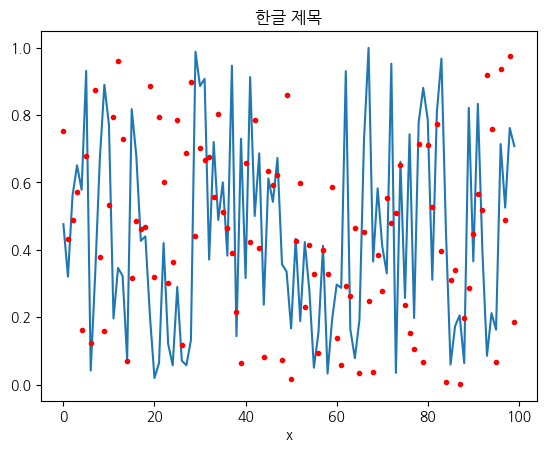

In [16]:
#@title 한글 차트
n = 100
plt.title('한글 제목')
plt.plot(np.random.rand(n))
plt.plot(np.random.default_rng().random(n), 'r.')
plt.xlabel('x')

## pivot - melt

<Axes: xlabel='month', ylabel='year'>

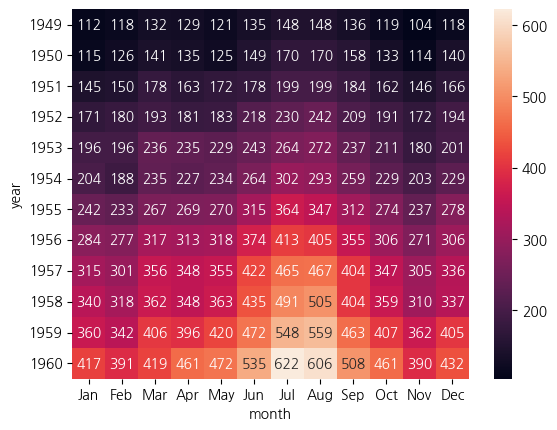

In [28]:
flt = sns.load_dataset('flights')
flt_p = flt.pivot(index='year', columns='month', values='passengers')
sns.heatmap(flt_p, annot=True, fmt='d')

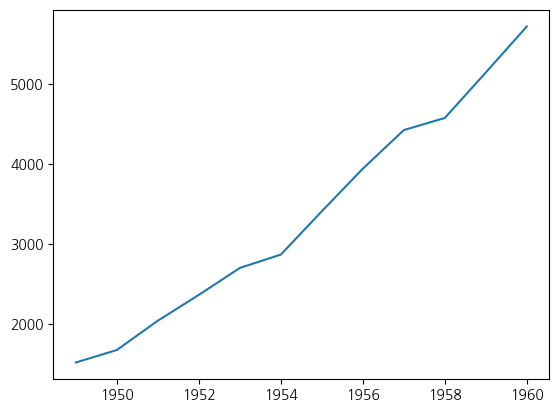

In [31]:
flt_m = flt_p.reset_index().melt(id_vars='year', var_name='month', value_name='passengers')
plt.plot(flt_m.groupby('year').sum('passengers'))

모델 학습 중...
학습 완료!
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


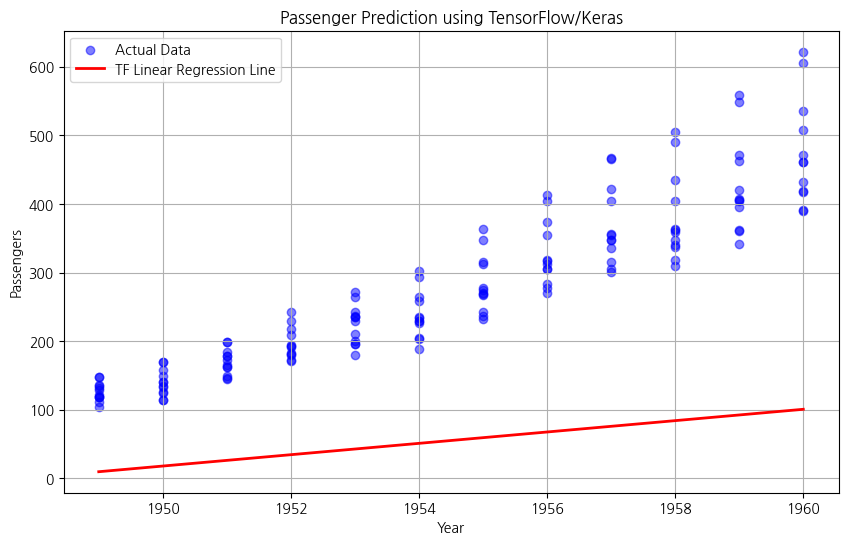

In [33]:
# --- 선형 회귀 예측 부분 시작 ---

import tensorflow as tf

# 1. 데이터 준비 (X: 연도, y: 승객 수)
# TensorFlow 입력은 보통 2차원 배열(batch_size, input_dim) 형태여야 하므로 reshape가 필요합니다.
X = flt_m['year'].values.reshape(-1, 1).astype(float)
y = flt_m['passengers'].values.astype(float)

# [중요] 데이터 정규화 (Feature Scaling)
# 연도 값이 1949처럼 크기 때문에 계산 효율을 위해 최소값을 빼서 0부터 시작하도록 만듭니다.
x_min = X.min()
X_scaled = X - x_min 

# 2. 모델 구성 (단일 Layer를 가진 선형 회귀 모델)
# Dense(1)은 y = wx + b 형태의 수식을 학습합니다.
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=(1,))
])

# 3. 모델 컴파일 (학습 설정)
# optimizer: 경사하강법 알고리즘 (adam), loss: 오차 측정 방식 (평균제곱오차)
model.compile(optimizer='adam', loss='mse')

# 4. 모델 학습
print("모델 학습 중...")
history = model.fit(X_scaled, y, epochs=2000, verbose=0) # 200번 반복 학습
print("학습 완료!")

# 5. 예측 및 시각화
y_pred = model.predict(X_scaled).flatten() # 모델이 예측한 값 추출

plt.figure(figsize=(10, 6))
# 실제 데이터 산점도 (Blue)
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data') 
# 선형 회귀 예측선 (Red)
plt.plot(X, y_pred, color='red', linewidth=2, label='TF Linear Regression Line')

plt.title('Passenger Prediction using TensorFlow/Keras')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

# --- 선형 회귀 예측 부분 끝 ---

In [40]:
len(y)

144